# Improved Model 

**Criticm of the old model**

Strengths:
- code runs successfully
- beginner-friendly
- clear baseline
- logistic regression is a reasonable starting model

Weaknesses:
- only accuracy used
- no confusion matrix / precision / recall / F1
- no stratified split
- no class distribution check
- no feature scaling
- no model comparison
- no algorithm justification
- no discussion of false negatives or medical context
- single train-test split only (no cross validation)


In this notebook we will split the initial code into multiple steps adding a new cell when theres a better improvement

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

## Improvement 1: Examine class distribution

The initial AI-generated code did not inspect the dataset distribution.
Understanding the balance between benign and malignant cases is important before training a model as this can help check if the dataset has any kind of bias. For example the dataset may have significantly more benign cases than malignant

In [4]:
import numpy as np

print("Class distribution:", np.bincount(y))

Class distribution: [212 357]


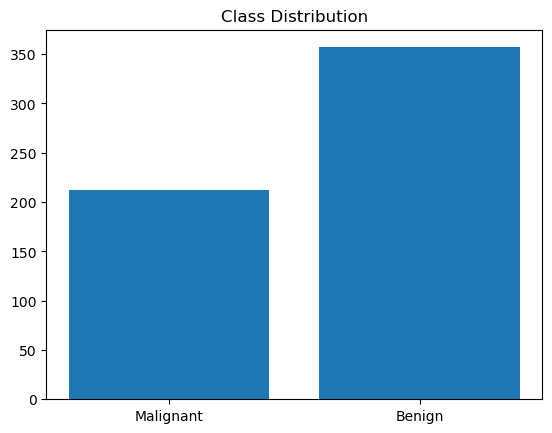

In [5]:
import matplotlib.pyplot as plt

labels = ["Malignant", "Benign"]
counts = np.bincount(y)

plt.bar(labels, counts)
plt.title("Class Distribution")
plt.show()

## Improvement 2: Stratified Train-Test Split

The original model used a standard train-test split without preserving class proportions.
A stratified split ensures the training and test sets maintain similar clas

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y, # added statrified sample 
    random_state=42
)

## Baseline Model : Logistic Regression 

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Improvement 3: Better Evaluation Metrics

The initial AI-generated code evaluated the model only using accuracy.
Additional metrics such as precision, recall, and F1-score provide a more complete evaluation.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[39  3]
 [ 1 71]]


## Improvement 4: Feature Scaling

Several machine learning algorithms are sensitive to differences in feature scale.
StandardScaler is applied to standardise feature magnitudes.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Improvement 5: Model Comparison

The initial code used only Logistic Regression.
Multiple models are compared to determine the most suitable algorithm.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    malignant_recall = recall_score(y_test, predictions, pos_label=0)

    results[name] = {
        "accuracy": accuracy,
        "malignant_recall": malignant_recall,
        "predictions": predictions
    }

    trained_models[name] = model

    print("\n" + "=" * 40)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Malignant Recall: {malignant_recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=data.target_names))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))


Model: Logistic Regression
Accuracy: 0.9825
Malignant Recall: 0.9762

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  1]
 [ 1 71]]

Model: Random Forest
Accuracy: 0.9561
Malignant Recall: 0.9286

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[39  3]
 [ 2 70]]

Model: SVM
Accuracy: 0.9825
Malignant Recall: 0.9762

Classification Report:
            

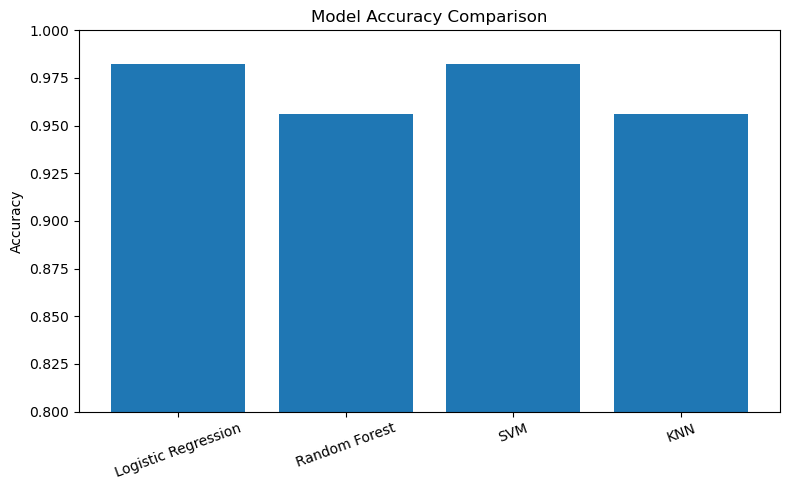

In [18]:
model_names = list(results.keys())
accuracy_scores = [results[name]["accuracy"] for name in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

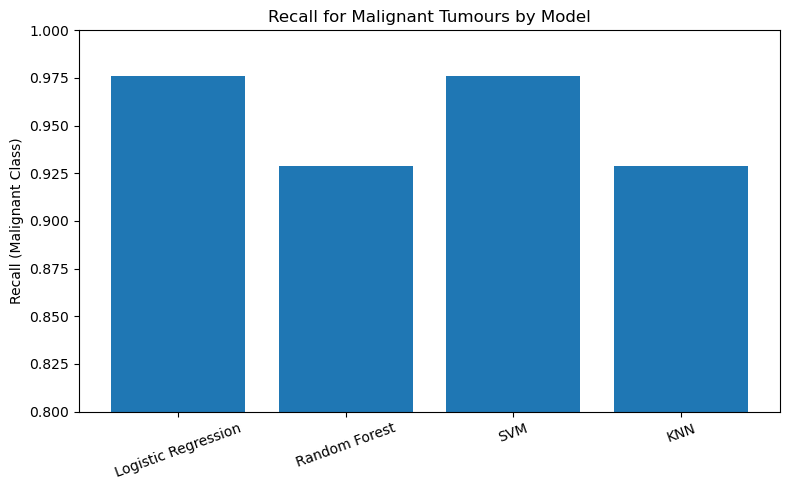

In [20]:
malignant_recalls = [results[name]["malignant_recall"] for name in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, malignant_recalls)
plt.title("Recall for Malignant Tumours by Model")
plt.ylabel("Recall (Malignant Class)")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

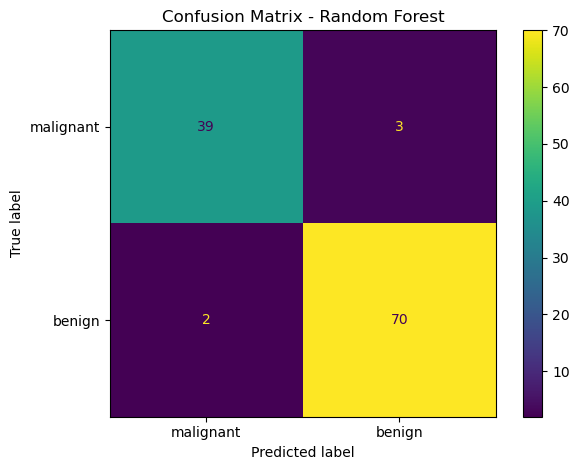

In [21]:
best_model_name = "Random Forest"
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]["predictions"]

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

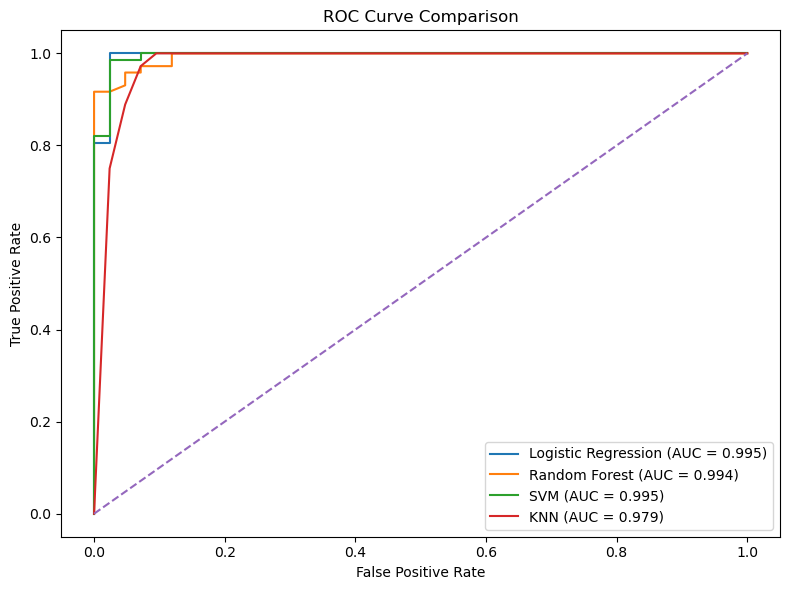

In [22]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_score = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()